# IMDb Movies Analysis — Sprint 3 Project (Turing College)

**Hello!! My name is Sofiia and this project is part of Sprint 3 at Turing College, where I will try to perform an Exploratory Data Analysis of the IMDb Top 1000 Movies dataset obtained from Kaggle.**

The dataset contains information about 1,000 of the most popular and highest-rated films listed on IMDb, covering a wide range of genres, directors, actors, ratings, revenues, and release years.

### Notebook Plan:
1) Download the dataset directly from Kaggle  
2) Define helper functions for cleaning and visualization     
3) Perform data cleaning — handling missing values, renaming columns, and adjusting data types  
4) Conduct exploratory analysis by answering various questions about the dataset 

Let's begin!

## 1. Downloading the dataset

In [1]:
##only if opendatasets was never installed before
#!pip install opendatasets

In [2]:
import opendatasets as od
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
dataset = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [4]:
def data_from_kaggle(dataset):
    """
    Download a Kaggle dataset using opendatasets and return the loaded DataFrame. Works with only one csv
    
    Args:
        dataset: Kaggle dataset URL.
    
    Returns:
        df (pd.DataFrame): CSV file found in the dataset folder, converted to pd.DataFrame
    """
    data_dir =  od.download(dataset)
    if data_dir is None:
        # Extract folder name from URL
        folder_name = dataset.split('/')[-1]
        data_dir = f'./{folder_name}'
    file = os.listdir(data_dir)
    csv_path = os.path.join(data_dir, file[0])
    df = pd.read_csv(csv_path)
    return df
    

In [5]:
imdb = data_from_kaggle(dataset) #you'll need your Kaggle credentials (username and API key) to use that

Skipping, found downloaded files in ".\imdb-dataset-of-top-1000-movies-and-tv-shows" (use force=True to force download)


## 2. Defining helper functions

In [6]:
def fill(df, column, median = True):
    """
    Fill missing (NaN) values in a specified DataFrame column using either the mean or median.

    Args:
        df (pd.DataFrame): The DataFrame containing the column to modify.
        column (str): The name of the column where NaN values will be filled.
        median (bool, optional): If True (default), fill NaNs with the column median.
                                 If False, fill NaNs with the column mean.

    Returns:
        str: A confirmation message specifying the method used (mean or median)
             and the value that replaced the missing entries.
    """
    if median:
        temp = df[column].median()
        stat = 'median'
    else:
        temp = df[column].mean()
        stat = 'mean'
    df[column] = df[column].fillna(temp)
    return f"Filled NaNs with {stat} of {temp}"

In [7]:
def hist_plot(df, column, title, xlabel, ylabel):
    """
    Plot a histogram of a specified DataFrame column and display its mean and median values.

    The function creates a histogram of the given column, then draws dashed vertical lines
    for the mean (in red) and the median (in yellow), each labeled with their respective values.

    Args:
        df (pd.DataFrame): The DataFrame containing the data to plot.
        column (str): The name of the column to visualize.
        title (str): The title of the histogram.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.

    Returns:
        None: Displays the histogram with annotated mean and median lines.
    """
    cl_mean = df[column].mean()
    cl_median = df[column].median()
    ax = df[column].plot(kind = 'hist')
    plt.axvline(cl_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {cl_mean:.2f}')
    plt.axvline(cl_median, color='yellow', linestyle='dashed', linewidth=2, label=f'Median: {cl_median:.2f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    plt.legend()
    plt.show()

#### Let's now have a look on our dataset!!

In [8]:
imdb.head(3)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


## 3.Data cleaning 
We will now examine our dataset and clean it to make it ready for analysis.
### Plan:
1) Identify unnecessary columns and remove them. Also, drop any duplicate rows.  
2) Rename columns where needed for better readability and understanding.  
3) Handle missing (NaN) values.  
4) Convert column types if needed.  
5) Perform any further processing steps as needed.  

### 1) Identify unnecessary columns or duplicate rows, drop them

In [9]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


We can immediately see 3 unessessary columns Star2, Star3, Star4 so we will drop them

In [10]:
imdb_cleaned = imdb.drop(columns = ['Star2', 'Star3', 'Star4'])

In [11]:
imdb_cleaned = imdb_cleaned.drop_duplicates()

### 2) Rename columns where needed for better readability 

In [12]:
imdb_cleaned = imdb_cleaned.rename({'Star1': 'Main star', 'Gross': 'Revenue(millions)', 'No_of_Votes' : 'Votes(millions)'}, axis = 1)
#we'll change Revenue and Votes to millions later

Since there are no stars 2, 3, or 4, it makes more sense to rename **“Star1”** to **“Main Star”**.  Also, the term **“Revenue”** seems more appropriate, so we’ll keep using it. We will later convert both votes and revenue to millions for easier visualization, we can’t do that just yet because of null values and data type issues, but we’ll fix it later! :)

### 3) Handle missing (NaN) values

Let's now have a closer look at null values, which columns have them and at what percentage

In [13]:
imdb_cleaned.isnull().sum()*100/len(imdb_cleaned)

Poster_Link           0.0
Series_Title          0.0
Released_Year         0.0
Certificate          10.1
Runtime               0.0
Genre                 0.0
IMDB_Rating           0.0
Overview              0.0
Meta_score           15.7
Director              0.0
Main star             0.0
Votes(millions)       0.0
Revenue(millions)    16.9
dtype: float64

We only have 3 columns with NaN values, and all of them are in the range of 10-17% of total DataFrame. This percentage doesn't really give us freedom to drop the columns or the rows, so we'll have to figure out a way to fill those values.

Let's start with **"Certificate"** column

In [14]:
imdb_cleaned["Certificate"].unique()

array(['A', 'UA', 'U', 'PG-13', 'R', nan, 'PG', 'G', 'Passed', 'TV-14',
       '16', 'TV-MA', 'Unrated', 'GP', 'Approved', 'TV-PG', 'U/A'],
      dtype=object)

Among all the unique categories we can see "unrated" which is essentially the same as nan, so we'll fill NaN values with this category

In [15]:
imdb_cleaned['Certificate'] = imdb_cleaned['Certificate'].fillna('Unrated')

In [16]:
#sanity check 
imdb_cleaned['Certificate'].isnull().sum()

#just to make sure we used the function correctly and everything is ok

0

We now want to fill **Meta score** and **Revenue**. Both categories are numerical(well we want them to be numerical in the end).

To decide how to fill the missing data — using the mean or the median —
we first need to check whether there are any outliers.

Outliers can heavily influence the mean, so if we detect strong outliers, the median will be the more reliable choice.

<Axes: xlabel='Meta_score'>

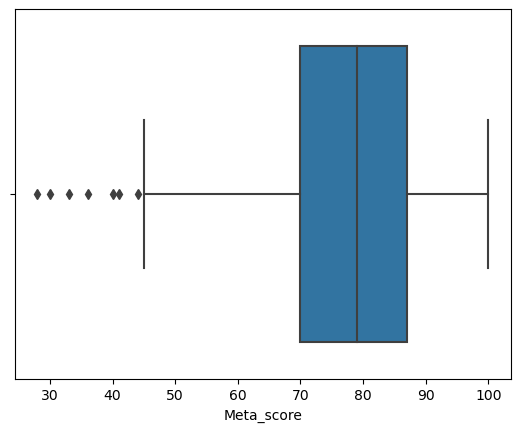

In [17]:
sns.boxplot(x = imdb_cleaned['Meta_score'])

Indeed, in **Meta score** we have some heavy lower outliers so it would be better to use median to fill NaN values

In [18]:
fill(imdb_cleaned,"Meta_score", median = True )

'Filled NaNs with median of 79.0'

In [19]:
imdb_cleaned["Meta_score"].isnull().sum() #sanity check

0

Let's now look at Revenue. Here we have an additional challenge because Revenue type is not numerical as we saw before

In [20]:
imdb_cleaned['Revenue(millions)'] = imdb_cleaned['Revenue(millions)'].str.replace(',', '').astype(float) #changing to float

In [21]:
imdb_cleaned['Revenue(millions)'] = imdb_cleaned['Revenue(millions)']/1e6 #changing to millions as mentioned early

Let's look if there are any outliers here:

<Axes: xlabel='Revenue(millions)'>

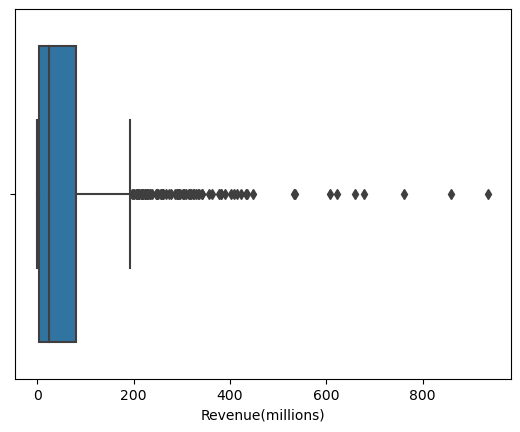

In [22]:
sns.boxplot(x = imdb_cleaned['Revenue(millions)'])

We have plenty outliers so we'll fill NaNs with median as well

In [23]:
fill(imdb_cleaned,"Revenue(millions)", median = True )

'Filled NaNs with median of 23.530892'

### 4) Convert column types if needed

From our first look at the DataFrame information, we can see that **Runtime** and **Released_Year** are both objects, when they really should be integers. Let's change that

In [24]:
imdb_cleaned.head(1) #quick reminder how our data looks

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,Votes(millions),Revenue(millions)
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,2343110,28.341469


In [25]:
imdb_cleaned['Runtime'] = imdb_cleaned['Runtime'].str.split(' ').str[0].str.strip() #leaving only integers in Runtime

Normally now we have to be able to convert both column types to integers, **but there is a little problem in Released_Year that blocks us from doing that  :(**

In [26]:
imdb_cleaned['Released_Year'].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

We have a string value "PG" that obviously cannot be changed to integer automatically. Let's investigate!!

In [27]:
imdb_cleaned[imdb_cleaned['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,Votes(millions),Revenue(millions)
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,269197,173.837933


Since this is the only row missing the information, and the information is publicly known in the internet,
we'll just manually change the value. After an easy research we learn that Appolo 13 was released in 1995

In [28]:
imdb_cleaned.loc[imdb_cleaned['Released_Year'] == 'PG', 'Released_Year'] = 1995

Now we can change both types to integers

In [29]:
imdb_cleaned = imdb_cleaned.astype({'Released_Year' : 'int', 'Runtime': 'int'})

### 5) Perform any further processing steps as needed

Let's leave only one **Genre** per film (the first one)

In [30]:
imdb_cleaned['Genre'] = imdb_cleaned['Genre'].str.split(",").str[0].str.strip()

Let's change **Votes** to millions 

In [31]:
imdb_cleaned['Votes(millions)'] = imdb_cleaned['Votes(millions)']/1e6

We're are all done for the part of cleaning, let's now perform some Exploratory Data Analysis and answer 24 question about this dataset. For convenience we'll create a copy of **imdb_cleaned** and name it **df**.

In [32]:
df = imdb_cleaned.copy()

## 4) EXPLORATORY DATA ANALYSIS

In this part we will try to answer **quite a few** questions about this dataset. Here is our list:
1) How many movies are in the dataset?  
2) What are the different genres present in the dataset?  
3) How many unique directors are listed in the dataset?  
4) What is the average IMDb rating of all movies?  
5) What is the highest-rated movie in the dataset?  
6) What is the oldest movie in the dataset?  
7) How many movies were released before the year 2000?  
8) What is the most common movie certificate in the dataset?  
9) Which director(s) have the most movies in the dataset?  
10) What are the top five highest-grossing movies?  
11) What is the average runtime of movies in the dataset?  
12) Plot the distribution of movie durations in a histogram.  
13) How does the number of votes correlate with IMDb rating?  
14) Which actor appears in the most movies in the dataset?  
15) How many movies have both IMDb rating and Metascore available?  
16) What are the top 3 most frequent genres in the dataset?  
17) How many movies were released in each decade?  
18) Which director has the highest average IMDb rating across their movies?  
19) What is the distribution of IMDb ratings across all movies? (Plot it in a histogram)  
20) Which genre has the highest average gross revenue?  
21) How many movies have an IMDb rating of 8.5 or higher and a Metascore above 85?  
22) Are movies with a longer runtime generally rated higher?  
23) What is the average gross revenue for movies directed by the top 10 directors with the most movies?  
24) What is the relationship between the number of votes and gross revenue?  

### Let's start!!

#### 1) How many movies are in the dataset?

In [33]:
print(f"There are {len(df)} movies in this dataset")

There are 1000 movies in this dataset


#### 2) What are the different genres present in the dataset?

In [34]:
res = ', '.join(df['Genre'].unique())
print(f"There are {len(df['Genre'].unique())} unique genres.\nHere is the list of all of them: {res}")


There are 14 unique genres.
Here is the list of all of them: Drama, Crime, Action, Biography, Western, Comedy, Adventure, Animation, Horror, Mystery, Film-Noir, Fantasy, Family, Thriller


#### 3) How many unique directors are listed in the dataset? 

In [35]:
print(f"There are {len(df['Director'].unique())} unique directors listed in dataset")

There are 548 unique directors listed in dataset


#### 4) What is the average IMDb rating of all movies?

In [36]:
avg_imdb = df['IMDB_Rating'].mean()
print(f"The average IMDb rating of all movies is {avg_imdb:.2f}")

The average IMDb rating of all movies is 7.95


 #### 5) What is the highest-rated movie in the dataset?

In [37]:
max_rank = df[df['IMDB_Rating'] == df['IMDB_Rating'].max()]
print(f"The highest-rated movie in the dataset is {max_rank['Series_Title'].item()}, with IMDB rating of {max_rank['IMDB_Rating'].item()}")

The highest-rated movie in the dataset is The Shawshank Redemption, with IMDB rating of 9.3


#### 6) What is the oldest movie in the dataset?

In [38]:
max_age = df[df['Released_Year'] == df['Released_Year'].min()]
print(f"The oldest movie in the dataset is {max_age['Series_Title'].item()}, with {max_age['Released_Year'].item()} as a year of release")

The oldest movie in the dataset is Das Cabinet des Dr. Caligari, with 1920 as a year of release


#### 7) How many movies were released before the year 2000?

In [39]:
print(f"There are {len(df[df['Released_Year']<2000])} films that were released before the year 2000")

There are 515 films that were released before the year 2000


#### 8) What is the most common movie certificate in the dataset?

In [40]:
common_cert = df['Certificate'].value_counts()
print(f'The most common movie certificate is {common_cert.index[0]} with {common_cert.iloc[0]} films rated') 

The most common movie certificate is U with 234 films rated


In [41]:
##if full table visualisation is needed undo the following comment
#common_cert

#### 9) Which director(s) have the most movies in the dataset?

In [42]:
max_mv = df['Director'].value_counts()
print(f'By quantity of films directed, top three directors are:')
for i in range(3):
    print(f'{i+1}. {max_mv.index[i]} with {max_mv.iloc[i]} films directed.')

By quantity of films directed, top three directors are:
1. Alfred Hitchcock with 14 films directed.
2. Steven Spielberg with 13 films directed.
3. Hayao Miyazaki with 11 films directed.


In [43]:
###if full table visualisation is needed undo the following comment
#max_mv

#### 10) What are the top five highest-grossing movies?

In [44]:
max_gross = df[['Series_Title', 'Revenue(millions)']].sort_values(by = 'Revenue(millions)', ascending = False)
print(f'Top five highest_grossing movies are:')
for i in range(5):
    print(f"{i+1}. {max_gross['Series_Title'].iloc[i]} with {max_gross['Revenue(millions)'].iloc[i]:.2f} million USD of revenue.")

Top five highest_grossing movies are:
1. Star Wars: Episode VII - The Force Awakens with 936.66 million USD of revenue.
2. Avengers: Endgame with 858.37 million USD of revenue.
3. Avatar with 760.51 million USD of revenue.
4. Avengers: Infinity War with 678.82 million USD of revenue.
5. Titanic with 659.33 million USD of revenue.


In [45]:
###if full table visualisation is needed undo the following comment
#max_gross

#### 11) What is the average runtime of movies in the dataset? 

In [46]:
print(f"The average runtime of movies in the dataset is {df['Runtime'].mean():.2f} minutes")


The average runtime of movies in the dataset is 122.89 minutes


#### 12) Plot the distribution of movie durations in a histogram.

We are using a function defined earlier, right at the beggining of the notebook

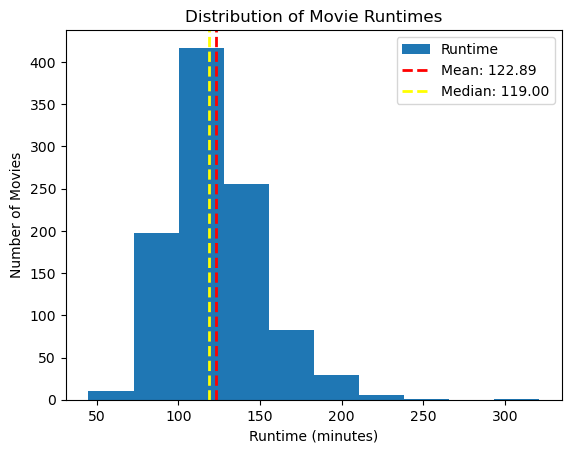

In [47]:
hist_plot(df, 'Runtime', "Distribution of Movie Runtimes", "Runtime (minutes)", "Number of Movies" )

Most movies have moderate runtimes within 70-150 minutes, but there are some very long movies (not many, only a few), which explains a slight difference between median and the mean

#### 13) How does the number of votes correlate with IMDb rating?

In [48]:
df[['IMDB_Rating', 'Votes(millions)']].corr()

,IMDB_Rating,Votes(millions)
IMDB_Rating,1.000000,0.494979
Votes(millions),0.494979,1.000000


IMDB rating and number of votes have positive correlation (meaning that if one increases, the second tends to increase as well). 

A coefficient 0.49 indicates that correlation is moderate, but it is not extremely strong

**We can interprete this correlation as follows:**  
Movies with higher IMDB rating tend to have more votes(possible explanation is that well-rated films are usually more popular and more viewed)

 #### 14) Which actor appears in the most movies in the dataset?

In [49]:
top_star = df['Main star'].value_counts()
print(f"{top_star.index[0]} appears in the most movies in the dataset, he is the main star is {top_star.iloc[0]} movies")
print(f"On the second and third place we have {top_star.index[1]} and {top_star.index[2]} with {top_star.iloc[1]} and {top_star.iloc[2]} movies respectfully.")

Tom Hanks appears in the most movies in the dataset, he is the main star is 12 movies
On the second and third place we have Robert De Niro and Al Pacino with 11 and 10 movies respectfully.


In [50]:
###if full table visualisation is needed undo the following comment
#top_star

#### 15) How many movies have both IMDb rating and Metascore available? 

Since we have cleaned the data and filled the missing values, for this question we'll use the raw dataset. From our cleaning process we know that every movie in the dataset has an IMDb rating, so in order to find an answer to this question we just need to look at how many films have Meta_score.

In [51]:
print(f"{len(imdb[imdb['Meta_score'].notna()])} films have both IMDb and Metascore rating available")

843 films have both IMDb and Metascore rating available


#### 16) What are the top 3 most frequent genres in the dataset?

In [52]:
freq_genre = df['Genre'].value_counts()
print(f'Top 3 most frequent genres in the dataset are:')
for i in range(3):
    print(f'{i+1}. {freq_genre.index[i]} with {freq_genre.iloc[i]} films.')

Top 3 most frequent genres in the dataset are:
1. Drama with 289 films.
2. Action with 172 films.
3. Comedy with 155 films.


In [53]:
###if full table visualisation is needed undo the following comment
#freq_genre

#### 17) How many movies were released in each decade?

A typical approach to this kind of problem would be to use binning with pd.cut() later.
However, since decades can be easily calculated directly from the release year, we’ll simply create a new column called **“Released_Decade”** by performing operations directly on the DataFrame.

In [54]:
df['Released_Decade'] = (df['Released_Year']//10)*10
#Ex: We have 1993, 1993//10 = 199, 199*10 = 1990 so here is our decade

In [55]:
films_dec = df['Released_Decade'].value_counts().sort_index()
films_dec

1920     11
1930     24
1940     35
1950     56
1960     73
1970     76
1980     89
1990    151
2000    237
2010    242
2020      6
Name: Released_Decade, dtype: int64

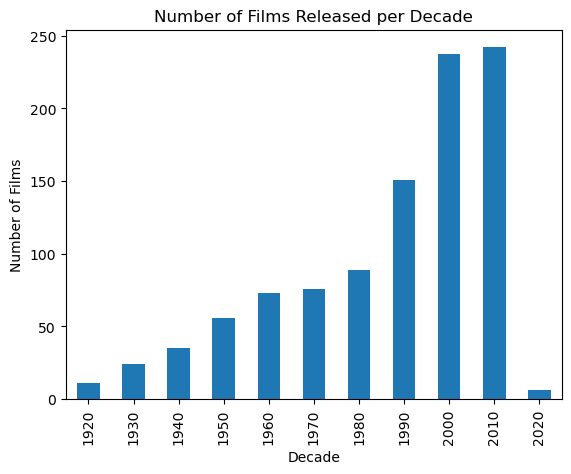

In [56]:
films_dec.plot(kind = 'bar')
plt.title('Number of Films Released per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Films')
plt.show()


Even though we might be tempted to talk about the growth of movie production based on this chart, we cannot do so, as this dataset is not representative of all films produced.
However, we can say that modern movies make up the largest share of the Top 1000 IMDb films, probably because they are better represented and were designed to be mass-produced.
The significant drop in the 2020s is expected, as this decade has only just started and fewer films qualify for inclusion.

#### 18) Which director has the highest average IMDb rating across their movies? 

In [57]:
top_direct = df.groupby('Director')['IMDB_Rating'].mean().sort_values(ascending = False)
print(f"{top_direct.index[0]} is a director with highest average ({top_direct.iloc[0]}) IMDb rating across their movies")

Frank Darabont is a director with highest average (8.95) IMDb rating across their movies


In [58]:
###if full table visualisation is needed undo the following comment
#top_direct

Just for the additional information here are the movies he directed:

In [59]:
df[df['Director']== "Frank Darabont"]['Series_Title'].tolist()

['The Shawshank Redemption', 'The Green Mile']

#### 19) What is the distribution of IMDb ratings across all movies? (Plot it in a histogram)

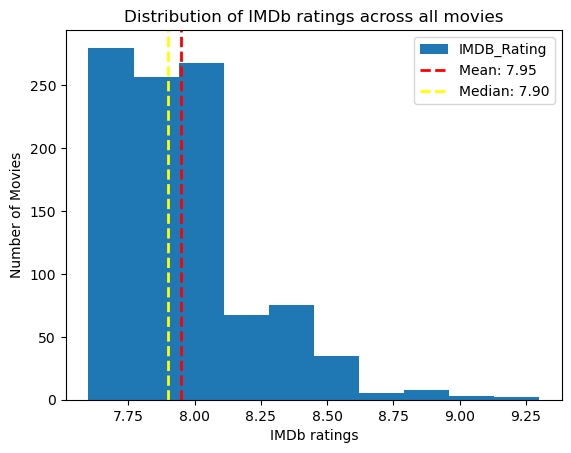

In [60]:
hist_plot(df, 'IMDB_Rating', "Distribution of IMDb ratings across all movies", "IMDb ratings", "Number of Movies" )

Most of the films have rating between 7.7 and 8.1, the mean and median are pretty close to each other meaning that the distribution is almost symmetrical(but there are still a few exceptionally well-rated movies above 8.6

#### 20) Which genre has the highest average gross revenue?

In [61]:
genre_gross = df.groupby('Genre')['Revenue(millions)'].mean().sort_values(ascending = False)
print(f"{genre_gross.index[0]} is the genre that has the highest gross revenue of {genre_gross.iloc[0]:.2f}")

Family is the genre that has the highest gross revenue of 219.56


In [62]:
##if full table visualisation is needed undo the following comment
#genre_gross

However, **it is important not to be fooled into thinking that the Family genre is one of the most popular**, simply because it has the highest average gross revenue.
In fact, the opposite is true. From Question 16, we can see that the Family genre is not even in the top three.
Further investigation (uncomment the next cell to view the result if needed) shows that the Family genre in this list includes only two movies — one of which (E.T. the Extra-Terrestrial) was a huge success, while the other (Charlie and the Chocolate Factory) was not particularly successful.
The average gross revenue is therefore inflated due to the very small sample size and the presence of a clear outlier.

In [63]:
##if full table visualisation is needed undo the following comment
#df[df['Genre'] == 'Family']

#### 21) How many movies have an IMDb rating of 8.5 or higher and a Metascore above 85?

The choice we made to fill in the NaN values in the Metascore column was to use the median value (79.0).
Therefore, answering this question with our cleaned DataFrame does not pose a problem, as all previously missing values now have a score of 79, which does not distort the results.
However, we understand that if the question were about scores below 85, we would need to use either the uncleaned dataset or a different filling technique — for example, assigning a placeholder value such as –100 to clearly distinguish missing entries.

In [64]:
meta_imdb = df[(df['IMDB_Rating']>=8.5) & (df['Meta_score'] >85)]
print(f"There are {len(meta_imdb)} movies with IMDb rating of of 8.5 or higher and a Metascore above 85")

There are 25 movies with IMDb rating of of 8.5 or higher and a Metascore above 85


In [65]:
##if full table visualisation is needed undo the following comment
#meta_imdb

 #### 22) Are movies with a longer runtime generally rated higher?

The answer on this question strongly depends on what type of rating are we choosing, if we are talking about IMDB, than yes we can see in the next cell that with the increase of time, IMDb ranking tends to increase as well. There is a moderate correlation but it is still existent.

What about the Meta_score? What about both combined?

In [66]:
df[['IMDB_Rating', 'Runtime']].corr()

,IMDB_Rating,Runtime
IMDB_Rating,1.000000,0.243096
Runtime,0.243096,1.000000


When we look at the Meta_score(next cell), we can see that the relation is actually negative. To be completely fair, we might as well say that is is nonexistent as 0.026 is an extremely low level of correlation, but we certainly can't say that longer movies are generally rated higher.

In [67]:
df[['Meta_score', 'Runtime']].corr()

,Meta_score,Runtime
Meta_score,1.000000,-0.026361
Runtime,-0.026361,1.000000


 What to do in this case? How to judge both combined? Let's look at the normalised average of both scores. Meta score is a measure of 100, IMDB is a measure of 10, let's normalise Meta score to 10 (divide it by 10) to give both measures the same level of importance.
 

In [68]:
temp = df.copy()
temp['Meta_normalised'] = temp['Meta_score']/10
temp['Avg_rating'] = (temp['Meta_normalised'] + temp['IMDB_Rating'])/2

In [69]:
temp[['Avg_rating', 'Runtime']].corr()

,Avg_rating,Runtime
Avg_rating,1.000000,0.029913
Runtime,0.029913,1.000000


Based on the correlation level here, we can conclude that there is no relation between rating and running time of the movie. The correlation index is extremely small.


We know that correlation is not a linear measure so such result should not shock us, however as a math student in college **my brain does not allow me to believe in this result unless I check manually that the formula is correct**, so the next part is really out of the program of this sprint and just me making sure that what we have as a result is correct.

### Off the program part
So basically what we want to do is just make sure that the calculated result works just fine. The only reason it can be bad is that maybe my change of variable (average normalised) somehow was calculated wrong. So we just go to the basic formulas and recalculate each part based on the given variables (the ones I didn't change, like IMDB). The formulas are following:
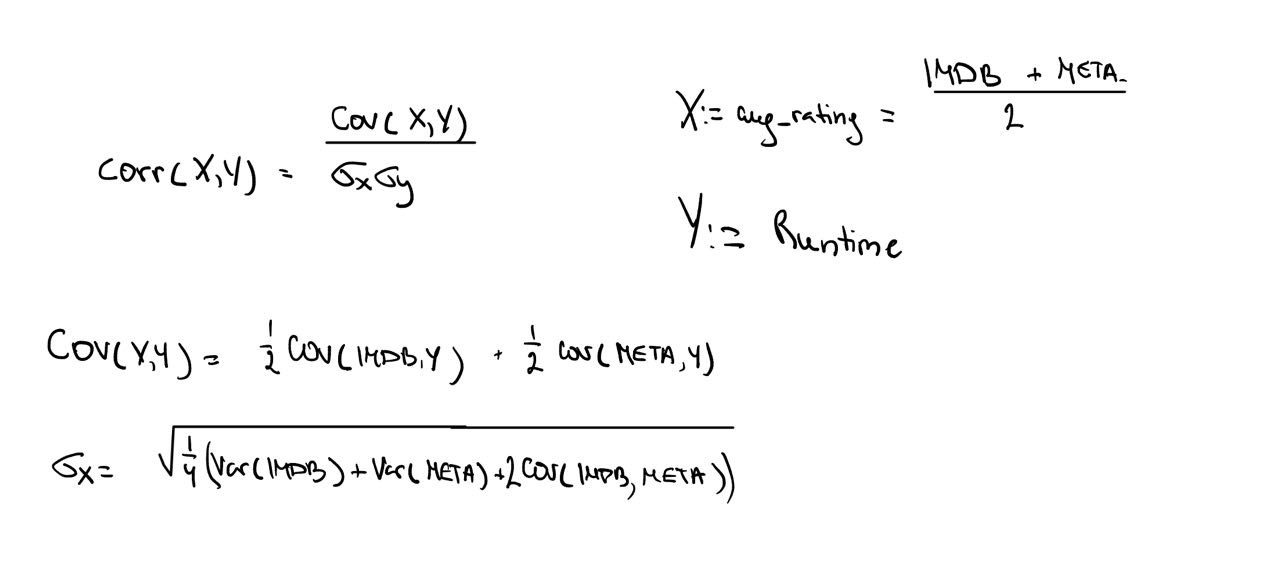 

Now we just find each part, each variance and covariance and just substitute into the formula.

In [70]:
#variance and covariance tables
IMDB_Y = temp[['IMDB_Rating', 'Runtime']].cov()
META_Y = temp[['Meta_normalised', 'Runtime']].cov()
IMDB_META = temp[['IMDB_Rating', 'Meta_normalised']].cov()

In [71]:
#each individual result
cov_IMDB_Y = IMDB_Y.loc['IMDB_Rating', "Runtime"]
var_IMDB = IMDB_Y.loc['IMDB_Rating', "IMDB_Rating"]
var_META = META_Y.loc['Meta_normalised', "Meta_normalised"]
cov_META_Y = META_Y.loc['Meta_normalised', "Runtime"]
cov_IMDB_META = IMDB_META.loc['IMDB_Rating', 'Meta_normalised']

In [72]:
std_X = (1/2)*np.sqrt(var_IMDB + var_META + 2*cov_IMDB_META) #standard deviation of normalised average
cov_X_Y = 0.5*cov_IMDB_Y + 0.5*cov_META_Y #covariance of runtime with normalised average

In [73]:
std_Y = temp['Runtime'].std() #stardard deviation of Runtime, nothing manual to calculate here

In [74]:
corr_X_Y = cov_X_Y/(std_X*std_Y) #basic correlation formula
corr_X_Y

0.029912867904425877

We can see that indeed we have obtained the same value as in the automatic formula below, meaning that such result has a right to exist and we can say one more time that there is no correlation between runtime and ratings

#### 23) What is the average gross revenue for movies directed by the top 10 directors with the most movies?

For this question we will use the quantity we have calculated before. max_mv - directors with most movies, and we'll just use the 10 first 

In [75]:
top10 = max_mv[:10].index.tolist() 

In [76]:
##if full table visualisation is needed undo the following comment
#top10

In [77]:
temp = df[df['Director'].isin(top10)]

In [78]:
##if full table visualisation is needed undo the following comment
#temp

In [79]:
top10_avg = temp['Revenue(millions)'].mean()
print(f"The average gross revenue for movies directed by the top 10 directors with most movies is {top10_avg:.2f} millions")

The average gross revenue for movies directed by the top 10 directors with most movies is 67.94 millions


#### 24) What is the relationship between the number of votes and gross revenue?

In [80]:
df[['Votes(millions)', 'Revenue(millions)']].corr()

,Votes(millions),Revenue(millions)
Votes(millions),1.000000,0.588428
Revenue(millions),0.588428,1.000000


There is a positive correlation between the number of votes and gross revenue, meaning that movies with more votes tend to generate higher revenue.
The correlation coefficient of 0.588 indicates a moderately strong relationship, confirming that the two variables are related.
However, we cannot conclude that one causes the other — this result only shows an association. Let's plot this relation.

In [81]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Main star,Votes(millions),Revenue(millions),Released_Decade
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,2.343110,28.341469,1990
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175,Crime,9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,1.620367,134.966411,1970
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152,Action,9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,2.303232,534.858444,2000
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202,Crime,9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,1.129952,57.300000,1970
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96,Crime,9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,0.689845,4.360000,1950


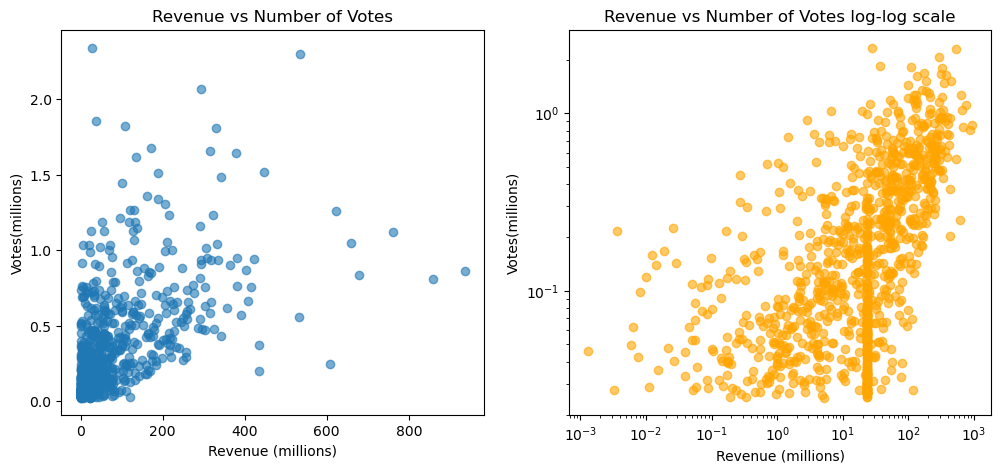

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#regular scatter plot
axes[0].scatter(df['Revenue(millions)'], df['Votes(millions)'], alpha=0.6)
axes[0].set_title('Revenue vs Number of Votes')
axes[0].set_xlabel('Revenue (millions)')
axes[0].set_ylabel('Votes(millions)')

#scatter plot with log-log scale
axes[1].scatter(df['Revenue(millions)'], df['Votes(millions)'], alpha=0.6, color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Revenue vs Number of Votes log-log scale')
axes[1].set_xlabel('Revenue (millions)')
axes[1].set_ylabel('Votes(millions)')

plt.show()

### Why did we use log-log scale on the right side?

We used log scale here because in the left graph(the basic one) we can see that there are few outliers(both on votes and revenue side) that compress our visualisation. Most of the films are squished in together and there is no way to see the actual relation between them. Log scale allows us to see the tendency rather than the actual value. Why? Because each step on the scale is a constant ratio (like 10^x) rather that an actual difference, so with log the difference betweem 10 to 100 is the same as to 100 to 1000, and since we have films with 1.3k revenue and 936.6 millions of revenue we need to have this adjusted scale

### Back to the graph

We can clearly see that there is a relationship between the two columns: movies with more votes tend to have higher revenue.
However, between 10^1 and 10^2 in revenue, we notice films with roughly the same revenue but very different numbers of votes. We can also notice that the "shape" of the graph is rather wide, meaning that similar votes can sometimes give us completely different revenue levels. 
This shows that while a general trend exists, the relationship is far from perfect — which is consistent with the correlation coefficient of 0.58.